In [1]:
from google.colab import files
uploaded = files.upload()

Saving Housing.csv to Housing.csv


Step 1: Dataset Selection & Import

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Load the dataset from your local directory
df = pd.read_csv('Housing.csv')
print('Dataset successfully loaded. Shape:', df.shape)

Dataset successfully loaded. Shape: (545, 13)


**Step 2: Data Inspection**

In [3]:
# Inspect dataset structure, data types, and missing values
print('--- Dataset Info ---')
print(df.info())

print('\n--- Summary Statistics ---')
print(df.describe())

print('\n--- First 5 Rows ---')
print(df.head())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None

--- Summary Statistics ---
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.

**Step 3: Exploratory Data Analysis (EDA)**

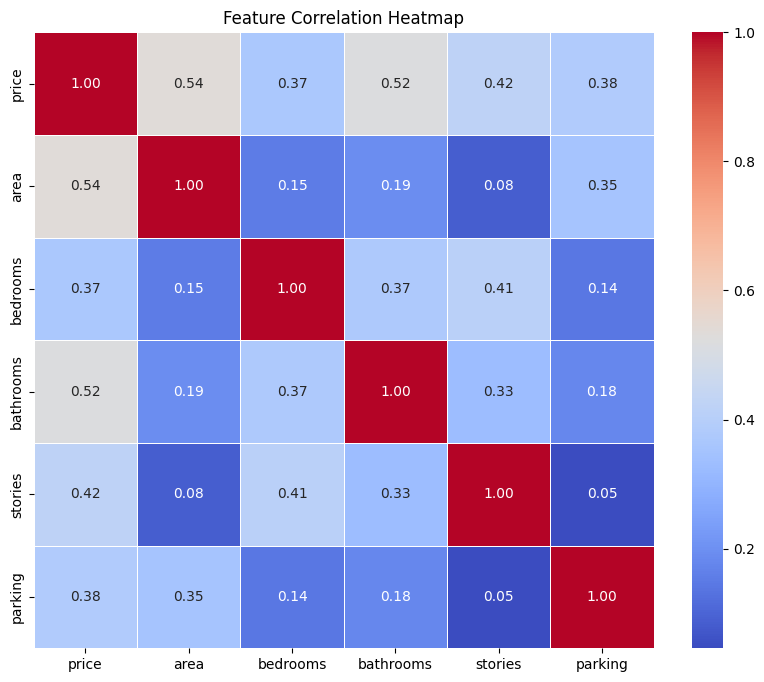

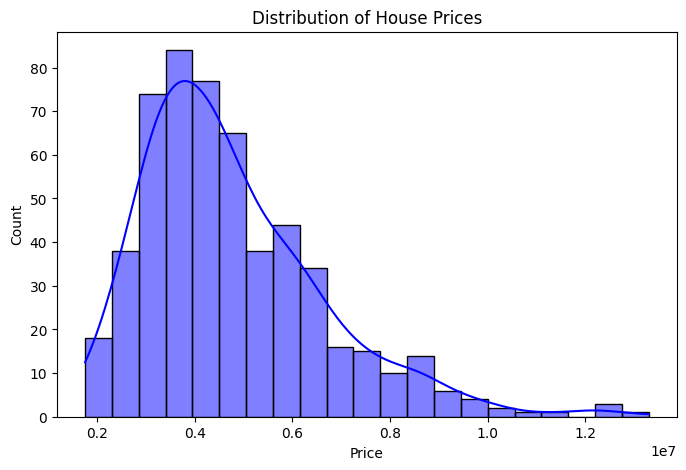

In [4]:
# Visualize feature distributions and correlation matrix to check for multicollinearity
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

# Distribution plot for the target variable (price)
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], kde=True, color='blue')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

**Step 4: Data Preprocessing & Feature Engineering**

In [5]:
# Map binary categorical variables ('yes'/'no' to 1/0)
binary_vars = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea',
]
for var in binary_vars:
  if var in df.columns:
    df[var] = df[var].map({'yes': 1, 'no': 0})

# One-hot encode multi-class categorical variables (e.g., furnishingstatus)
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

print('Preprocessing complete. Cleaned columns:', df.columns.tolist())

Preprocessing complete. Cleaned columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


**Step 5: Data Splitting**

In [6]:
# Define Features (X) and Target variable (y)
X = df.drop(columns=['price'])
y = df['price']

# Split data into 80% training and 20% testing sets[cite: 1]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Training set shape: {X_train.shape}')
print(f'Testing set shape: {X_test.shape}')

Training set shape: (436, 13)
Testing set shape: (109, 13)


**Step 6: Model Fitting**

In [7]:
# Initialize and fit the Multiple Linear Regression model[cite: 1]
model = LinearRegression()
model.fit(X_train, y_train)
print('Linear Regression model successfully trained!')

Linear Regression model successfully trained!


**Step 7: Model Evaluation**

In [8]:
# Predict on test data and evaluate using MAE, MSE, and R^2 score[cite: 1]
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'R^2 Score: {r2:.4f}')

Mean Absolute Error (MAE): 970043.40
Mean Squared Error (MSE): 1754318687330.66
R^2 Score: 0.6529


**Step 8: Plotting and Interpretation**

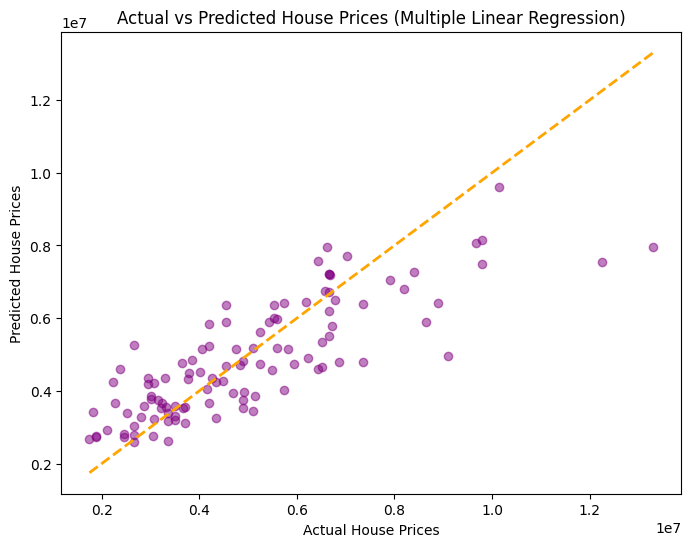


Model Coefficients Interpretation:
                        Feature   Coefficient
                           area  2.359688e+02
                       bedrooms  7.677870e+04
                      bathrooms  1.094445e+06
                        stories  4.074766e+05
                       mainroad  3.679199e+05
                      guestroom  2.316100e+05
                       basement  3.902512e+05
                hotwaterheating  6.846499e+05
                airconditioning  7.914267e+05
                        parking  2.248419e+05
                       prefarea  6.298906e+05
furnishingstatus_semi-furnished -1.268818e+05
   furnishingstatus_unfurnished -4.136451e+05

Intercept ($eta_0$): 260032.36


In [9]:
# Plot actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='purple')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='orange',
    linestyle='--',
    lw=2,
)
plt.xlabel('Actual House Prices')
plt.ylabel('Predicted House Prices')
plt.title('Actual vs Predicted House Prices (Multiple Linear Regression)')
plt.show()

# Interpret coefficients
coefficients_df = pd.DataFrame(
    {'Feature': X.columns, 'Coefficient': model.coef_}
)
print('\nModel Coefficients Interpretation:')
print(coefficients_df.to_string(index=False))
print(f'\nIntercept ($\beta_0$): {model.intercept_:.2f}')